In [9]:
# before mandate + face_mask
# Random Forest

In [10]:
# Read data
import pandas as pd
import numpy as np

X_train = pd.read_csv("../train_test/before_train_X_face_mask.csv")
y_train = pd.read_csv("../train_test/before_train_y_face_mask.csv")

X_test = pd.read_csv("../train_test/before_test_X_face_mask.csv")
y_test = pd.read_csv("../train_test/before_test_y_face_mask.csv")

# Squeeze y to 1D
y_train = y_train.squeeze()
y_test = y_test.squeeze()

In [11]:
# Random upsampling of training set
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=3034)

X_train_fm_before_ros, y_train_fm_before_ros = ros.fit_resample(X_train, y_train)

In [12]:
# # Hyperparameter tuning for RandomForest using Optuna
# # The objective is to maximize ROC-AUC using 5-fold stratified cross-validation

# import optuna
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.model_selection import StratifiedKFold, cross_val_score

# def objective(trial):
#     model = RandomForestClassifier(
#         n_estimators=250,
#         max_depth=trial.suggest_int("max_depth", 2, 30),
#         min_samples_split=trial.suggest_int("min_samples_split", 2, 30),
#         min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 30),
#         max_features=trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
#         random_state=3034,
#         n_jobs=-1
#     )

#     cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=3034)

#     auc_scores = cross_val_score(
#         model,
#         X_train_fm_before_ros,
#         y_train_fm_before_ros,
#         cv=cv,
#         scoring="roc_auc",
#         n_jobs=-1
#     )

#     return auc_scores.mean()

# optuna.logging.set_verbosity(optuna.logging.WARNING)
# sampler = optuna.samplers.TPESampler(seed=3034)
# study = optuna.create_study(
#     direction="maximize",
#     sampler=sampler
# )
# study.optimize(objective, n_trials=200)

# print("Best params:", study.best_params)

# import json
# with open("../model/rf_before_fm_params.json", "w") as f:
#     json.dump(study.best_params, f)


In [13]:
# Initialize the model with the best hyperparameters found by Optuna
from sklearn.ensemble import RandomForestClassifier
import json

with open("../model/rf_before_fm_params.json", "r") as f:
    best_params = json.load(f)

print("Best params:", best_params)

best_rf_fm_before = RandomForestClassifier(
    n_estimators=250,
    **best_params,
    random_state=3034,
    n_jobs=-1
)

# Model Fitting
best_rf_fm_before.fit(X_train_fm_before_ros, y_train_fm_before_ros)

Best params: {'max_depth': 30, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt'}


,n_estimators,250
,criterion,'gini'
,max_depth,30
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [14]:
# Generate predictions on the test set
y_pred = best_rf_fm_before.predict(X_test)
y_prob = best_rf_fm_before.predict_proba(X_test)[:, 1]

# Evaluate model performance
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
auc = roc_auc_score(y_test, y_prob)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)
print("ROC-AUC  :", auc)

Accuracy : 0.8201414617716403
Precision: 0.6921797004991681
Recall   : 0.5437908496732026
F1-score : 0.6090775988286969
ROC-AUC  : 0.8606535354613714


In [15]:
# Estimate stable feature importance by repeatedly refitting the model
# with different random resampling

feature_names = X_train.columns
importance_list = []

for i in range(100):
    # Different seeds
    ros = RandomOverSampler(random_state=3034 + i)
    X_res, y_res = ros.fit_resample(X_train, y_train)

    # Using best model
    model = RandomForestClassifier(
        n_estimators=250,
        **best_params,
        random_state=3034 + i,
        n_jobs=-1
    )

    model.fit(X_res, y_res)

    importance_list.append(model.feature_importances_)

importance_array = np.array(importance_list)  

median_importance = np.median(importance_array, axis=0)
q1 = np.percentile(importance_array, 25, axis=0)
q3 = np.percentile(importance_array, 75, axis=0)
iqr = q3 - q1

importance_df = pd.DataFrame({
    "feature": feature_names,
    "median_importance": median_importance,
    "q1": q1,
    "q3": q3,
    "iqr": iqr
}).sort_values(by="median_importance", ascending=False)

# Remove features importance start with "state"
importance_df = importance_df[
    ~importance_df["feature"].str.startswith("state")
]

display_name_map = {
    "protective_behaviour_nomask_scale": "Non-mask Protective Behaviour Score",
    "age": "Age",
    "week_number": "Survey Week",
    "i2_health": "Non-household Contacts",
    "r1_1": "Perceived Personal Risk",
    "cantril_ladder": "Life Satisfaction",
    "r1_2": "Perceived Infection Likelihood",
    "household_size": "Household Size",
    "gender_Male": "Male",
    "WCRex2_A lot of confidence": "High NHS Confidence"
}

importance_df["feature"] = importance_df["feature"].replace(display_name_map)

# Save data
importance_df.to_csv("../importance/rf_before_face_mask_importance.csv", index=False)

print(importance_df.head(10))

                                feature  median_importance        q1  \
7   Non-mask Protective Behaviour Score           0.110740  0.109659   
1                                   Age           0.092475  0.091623   
6                           Survey Week           0.088702  0.088089   
0                Non-household Contacts           0.071881  0.071220   
4               Perceived Personal Risk           0.058526  0.057846   
3                     Life Satisfaction           0.052728  0.052321   
5        Perceived Infection Likelihood           0.052082  0.051540   
2                        Household Size           0.040442  0.040207   
15                                 Male           0.017118  0.017005   
31                  High NHS Confidence           0.014811  0.014663   

          q3       iqr  
7   0.112192  0.002533  
1   0.093198  0.001575  
6   0.089237  0.001149  
0   0.072415  0.001195  
4   0.059248  0.001402  
3   0.053057  0.000736  
5   0.052682  0.001143  
2   0.0

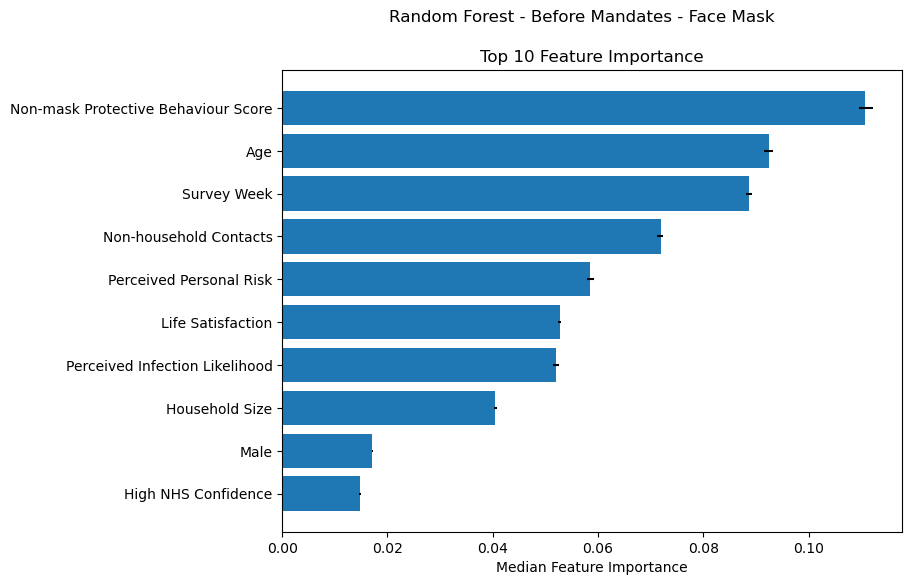

In [16]:
import matplotlib.pyplot as plt

plot_df = importance_df.head(10).copy()

fig, ax = plt.subplots(figsize=(8, 6))

ax.barh(
    plot_df["feature"],
    plot_df["median_importance"],
    xerr=[
        plot_df["median_importance"] - plot_df["q1"],
        plot_df["q3"] - plot_df["median_importance"]
    ]
)

ax.set_xlabel("Median Feature Importance")
ax.invert_yaxis()

ax.set_title("Top 10 Feature Importance", fontsize=12)
fig.suptitle("Random Forest - Before Mandates - Face Mask", fontsize=12)

plt.show()